# Solar panel and battery analysis
This python code will cover the solar panel and battery efficiencies for various tests.

### Setting up project and running all rate files
Here the project is set up, and data is imported.

In [19]:
""
"  This Code is created by Daan Schat - 5169801 - TU Delft Master Student SET"
"  for the Green Village energy hub project"
""

# Setting up the environment:
import matplotlib.pyplot as plt
import random
import pandas as pd
import numpy as np
import os
import chardet
from IPython.display import display, Javascript

# Variables & Constants:
LHV_H2 = 120000000 # J/kg
HHV_H2 = 142000000 # J/kg
MolarVolume = 22.414 # L/mol.f
MolarMass = 2.016 # g/mol
H2Density = MolarMass/MolarVolume # g/L

subfolder = "./All dataframes/dataframes-1-min"
solarsubfolder = "All dataframes/dataframes-solar"


pickle_files = [f for f in os.listdir(subfolder) if f.endswith(".pkl")]

DataframesToLoad = ["PV_Inverter_Active_Power"]

for var_name in DataframesToLoad:
    globals()[var_name] = pd.read_pickle(os.path.join(subfolder, f"{var_name}.pkl"))
    print(f"Loaded {var_name} from {subfolder}")

globals()['solar_data'] = pd.read_pickle(os.path.join(solarsubfolder, "solar_data.pkl"))


Loaded PV_Inverter_Active_Power from ./All dataframes/dataframes-1-min


In [21]:
# Setting up plotting layout
figdim=(10, 6)
title_fontsize  = 18
label_fontsize  = 16
tick_fontsize   = 14
legend_fontsize = 14

# The following fucntions plot figures on the data and/or do some calculations.
# The functions just simply take the new pandas dataframes by their string name: E.g. 'Battery_Current'

# The fplot function simply plots a feature over time (and can take multiple features to be plotted into one figure)
def fplot(*vars):
    minval = maxval = 0
    measurement_types = set()
    plt.figure(figsize=figdim)
    for var in vars:
        if var in globals():
            data = globals()[var] # Needed to recall the data from their string name
            device_measurement_label = f"{data['device_id'].iloc[0]} - {data['measurement_id'].iloc[0]}"
            plt.plot(data['time'], data['value_float'], marker='', linestyle='-',linewidth = 3, label=var,)
            measurement_types.add(data['measurement_id'].iloc[0])

            #Determines size needed of the canvas (surely could be improved)
            if minval > min(data['value_float']):
                minval = min(data['value_float'])
            if maxval < max(data['value_float']):
                maxval = max(data['value_float'])
        else:
            print(f"Variable '{var}' not found!")

    # Fixes labeling for multiple features to be plotted in one figure
    if len(measurement_types) == 1:
        plt.ylabel(f"Measurements: ({measurement_types.pop()})", fontsize=label_fontsize)
    else:
        plt.ylabel(f"Measurements: ({', '.join(sorted(measurement_types))})", fontsize=label_fontsize)

    # Plotting settings:
    plt.xlabel('Time', fontsize=label_fontsize)
 #  plt.ylabel(f'Value {data['measurement_id']}', fontsize=label_fontsize)
    plt.xlim(min(data['time']), max(data['time']))
    plt.ylim(minval*1.2, maxval*1.2)
    plt.title('Device Measurements Over Time',fontsize=title_fontsize)
    plt.xticks(rotation=45, fontsize=tick_fontsize)
    plt.tight_layout()
    plt.legend(fontsize=legend_fontsize)
    plt.grid(True)
    plt.show()

# These functions handle integration (area under curve) For energy (W) to (kWh) and H2 flow (NL/h) to (kg & kWh)
def integrate(var):
    if var in globals():
        data = globals()[var]
        time = data['time']
        values = data['value_float']
        time_numeric = (time - time.iloc[0]).dt.total_seconds().astype(int)
        integral = np.trapz(values, time_numeric)
    else:
        print(f"Variable '{var}' not found!")

    plt.figure(figsize=figdim)
    plt.plot(time, values, label='Data')
    plt.fill_between(time, values, alpha=0.2, label=f'Integrated Area: {integral_value}')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.xlim(min(time),max(time))
    plt.title('Integrated data')
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    return integral


# Called upon, this function gives a plot with integrated results of power, and gives the energy content (Pos,Neg, and cumulative)
def integrate_hr(var):
    if var in globals():
        data = globals()[var]
        time = data['time']
        values = data['value_float']
        time_numeric = (time - time.iloc[0]).dt.total_seconds().astype(int)
        
        # We seperate positive and negative data in case power can be negative and positive (Battery)
        positive_values = np.where(values > 0, values, 0)
        negative_values = np.where(values < 0, values, 0)
        kWh_pos = np.trapz(positive_values, time_numeric)/3600000 # Perform integration for positive values
        kWh_neg = np.trapz(negative_values, time_numeric)/3600000 # Perform integration for negative values
        joules = np.trapz(values, time_numeric)
        energy_kWh = joules / 3600000
    else:
        print(f"Variable '{var}' not found!")  

    plt.figure(figsize=figdim)
    plt.plot(time, values, label='Power Data', linewidth = 2)
    plt.fill_between(time, positive_values, alpha=0.2, label=f'Positive Energy (kWh): {kWh_pos:.3f}', color='green')
    plt.fill_between(time, negative_values, alpha=0.2, label=f'Negative Energy (kWh): {kWh_neg:.3f}', color='red')
    plt.xlabel('Time')
    plt.ylabel('Power [W]')
    plt.xlim(min(time),max(time))
    plt.ylim(min(values),max(values)*1.2)

    plt.title('Electric power and energy over time')
    plt.legend( loc='upper right')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    return energy_kWh, kWh_pos, kWh_neg


def integrate_hr_inverter(var):
    if var in globals():
        data = globals()[var]
        time = data['time']
        values = data['value_float']
        time_numeric = (time - time.iloc[0]).dt.total_seconds().astype(int)
        
        # Separate positive and negative data
        positive_values = np.where(values > 0, values, 0)
        negative_values = np.where(values < 0, values, 0)
        kWh_pos = np.trapz(positive_values, time_numeric) / 3600000  # Integration for positive values
        kWh_neg = np.trapz(negative_values, time_numeric) / 3600000  # Integration for negative values
        joules = np.trapz(values, time_numeric)
        energy_kWh = joules / 3600000
    else:
        print(f"Variable '{var}' not found!")  
        return None, None, None

    # Plotting
    plt.figure(figsize=figdim)
    plt.plot(time, values, label='Power Data', linewidth = 2)
    plt.fill_between(time, positive_values, alpha=0.2, label=f'Generated PV Energy (kWh): {kWh_pos:.3f}', color='green')
    
    # Plot negative energy only if it exists
    if np.any(negative_values != 0):  # Check if there are non-zero negative values
        plt.fill_between(time, negative_values, alpha=0.2, label=f'Negative Energy (kWh/): {kWh_neg:.3f}', color='red')
    
    plt.xlabel('Time')
    plt.ylabel('Inverter Power [W]')
    plt.xlim(min(time), max(time))
    plt.ylim(min(values),max(values)*1.2)
    plt.title('TGV PV inverter power and energy over time')
    plt.legend(loc='upper right')  # Set legend location to top-right corner
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"figures/Solar Report/InverterEnergy.png")
    plt.show()

    return energy_kWh, kWh_pos, kWh_neg


def integrate_hr_forecast(var):
    if var in globals():
        data = globals()[var]
        time = data['time']
        values = data['value_float']
        time_numeric = (time - time.iloc[0]).dt.total_seconds().astype(int)
        
        # Separate positive and negative data
        positive_values = np.where(values > 0, values, 0)
        negative_values = np.where(values < 0, values, 0)
        kWh_pos = np.trapz(positive_values, time_numeric) / 3600000  # Integration for positive values
        kWh_neg = np.trapz(negative_values, time_numeric) / 3600000  # Integration for negative values
        joules = np.trapz(values, time_numeric)
        energy_kWh = joules / 3600000
    else:
        print(f"Variable '{var}' not found!")  
        return None, None, None

    # Plotting
    plt.figure(figsize=figdim)
    plt.plot(time, values, label='Power Data', linewidth = 2)
    plt.fill_between(time, positive_values, alpha=0.2, label=f'Total Energy irradiated (kWh/m2): {kWh_pos:.3f}', color='green')
    
    # Plot negative energy only if it exists
    if np.any(negative_values != 0):  # Check if there are non-zero negative values
        plt.fill_between(time, negative_values, alpha=0.2, label=f'Negative Energy (kWh/m2): {kWh_neg:.3f}', color='red')
    
    plt.xlabel('Time')
    plt.ylabel('Irradiance [W/m2]')
    plt.xlim(min(time), max(time))
    plt.ylim(min(values),max(values)*1.2)
    plt.title('Historical data on solar irradiance at GV from Open Meteo')
    plt.legend(loc='upper right')  # Set legend location to top-right corner
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"figures/Solar Report/HistoricalOpenMeteoGTI.png")
    plt.show()



    return energy_kWh, kWh_pos, kWh_neg


def integrate_hr_pyrano(var):
    if var in globals():
        data = globals()[var]
        time = data['time']
        values = data['value_float']
        time_numeric = (time - time.iloc[0]).dt.total_seconds().astype(int)
        
        # Separate positive and negative data
        positive_values = np.where(values > 0, values, 0)
        negative_values = np.where(values < 0, values, 0)
        kWh_pos = np.trapz(positive_values, time_numeric) / 3600000  # Integration for positive values
        kWh_neg = np.trapz(negative_values, time_numeric) / 3600000  # Integration for negative values
        joules = np.trapz(values, time_numeric)
        energy_kWh = joules / 3600000
    else:
        print(f"Variable '{var}' not found!")  
        return None, None, None

    # Plotting
    plt.figure(figsize=figdim)
    plt.plot(time, values, label='Power Data', linewidth = 2)
    plt.fill_between(time, positive_values, alpha=0.2, label=f'Total Energy irradiated (kWh/m2): {kWh_pos:.3f}', color='green')
    
    # Plot negative energy only if it exists
    if np.any(negative_values != 0):  # Check if there are non-zero negative values
        plt.fill_between(time, negative_values, alpha=0.2, label=f'Negative Energy (kWh/m2): {kWh_neg:.3f}', color='red')
    
    plt.xlabel('Time')
    plt.ylabel('Irradiance [W/m2]')
    plt.xlim(min(time), max(time))
    plt.ylim(min(values),max(values)*1.2)
    plt.title('Pyranometer data on solar irradiance from TGV office roof')
    plt.legend(loc='upper right')  # Set legend location to top-right corner
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"figures/Solar Report/PyranometerGV.png")
    plt.show()
    
    return energy_kWh, kWh_pos, kWh_neg


### Irradiance Data
The following irradiance data is historical data that is gathered from openmeteo. It gives us the solar irradiance (GTI) for a tilt of 45 degrees, and azimuth of 67 degrees (current energy hub orientation). The output is given per square meter, at the time of testing. 

Coordinates 52.00600051879883°N 4.349999904632568°E
Elevation 4.0 m asl
Timezone b'Europe/Amsterdam' b'GMT+1'
Timezone difference to GMT+0 3600 s
                         date  temperature_2m  global_tilted_irradiance
0   2024-08-04 23:00:00+00:00       18.500000                       0.0
1   2024-08-04 23:15:00+00:00       18.500000                       0.0
2   2024-08-04 23:30:00+00:00       18.549999                       0.0
3   2024-08-04 23:45:00+00:00       18.600000                       0.0
4   2024-08-05 00:00:00+00:00       18.650000                       0.0
..                        ...             ...                       ...
187 2024-08-06 21:45:00+00:00       21.799999                       0.0
188 2024-08-06 22:00:00+00:00       21.700001                       0.0
189 2024-08-06 22:15:00+00:00       21.549999                       0.0
190 2024-08-06 22:30:00+00:00       21.400000                       0.0
191 2024-08-06 22:45:00+00:00       21.250000                 

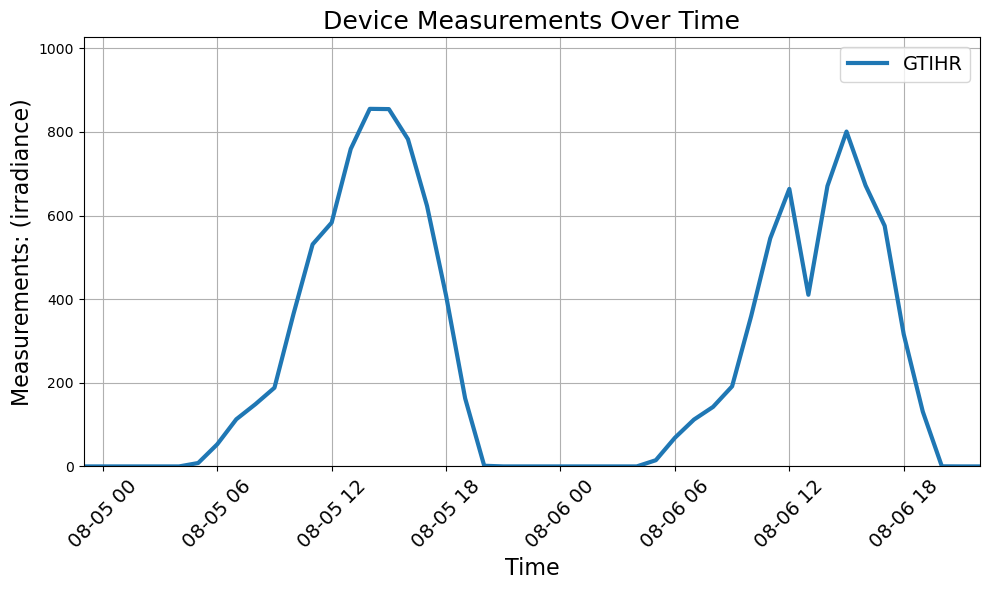

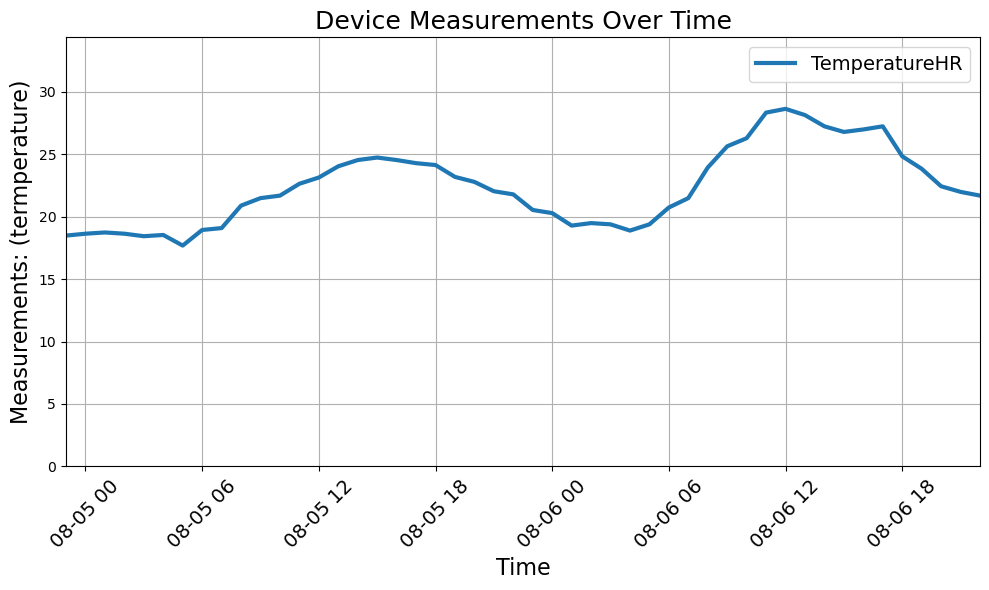

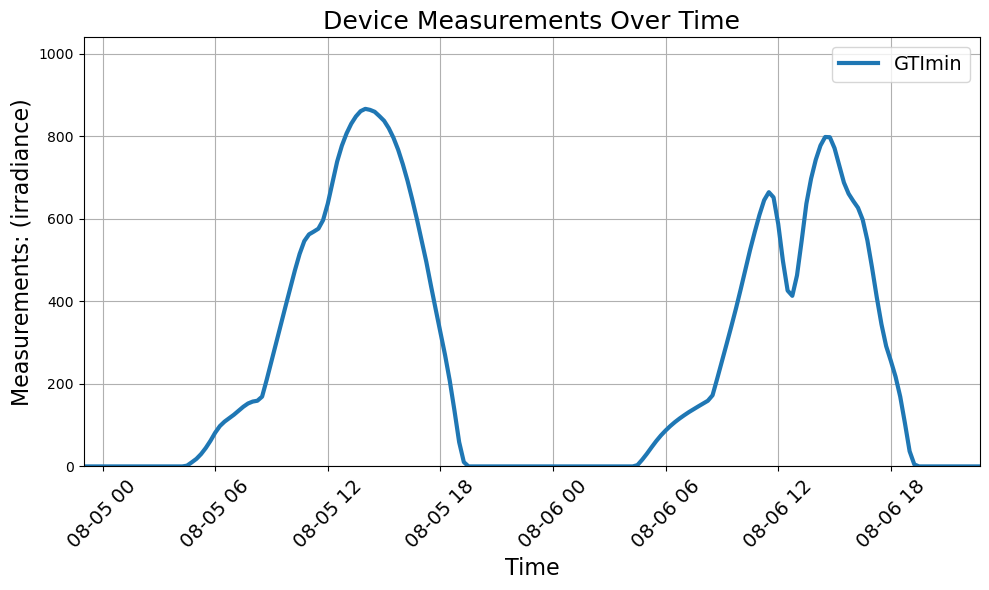

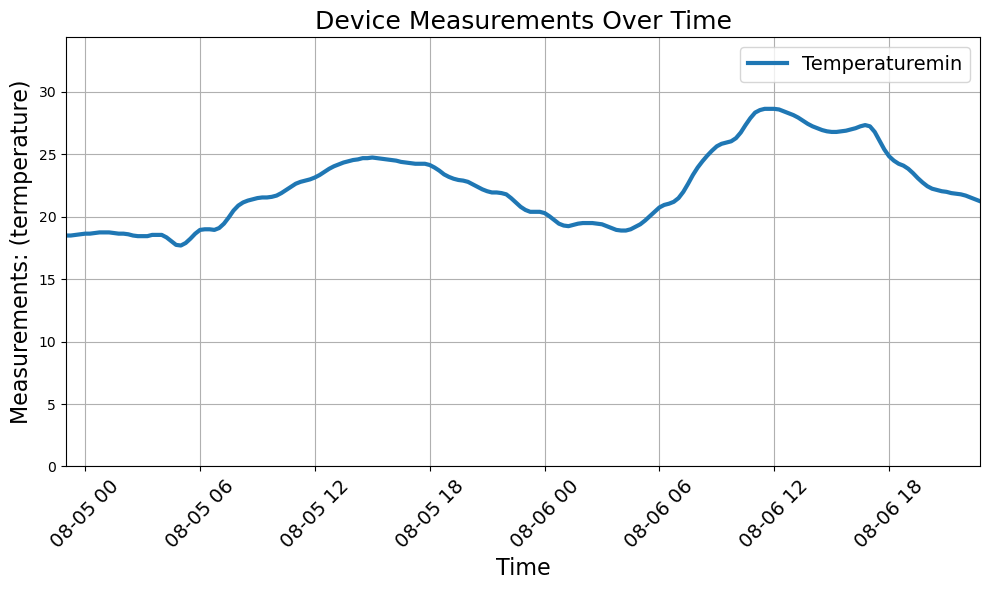

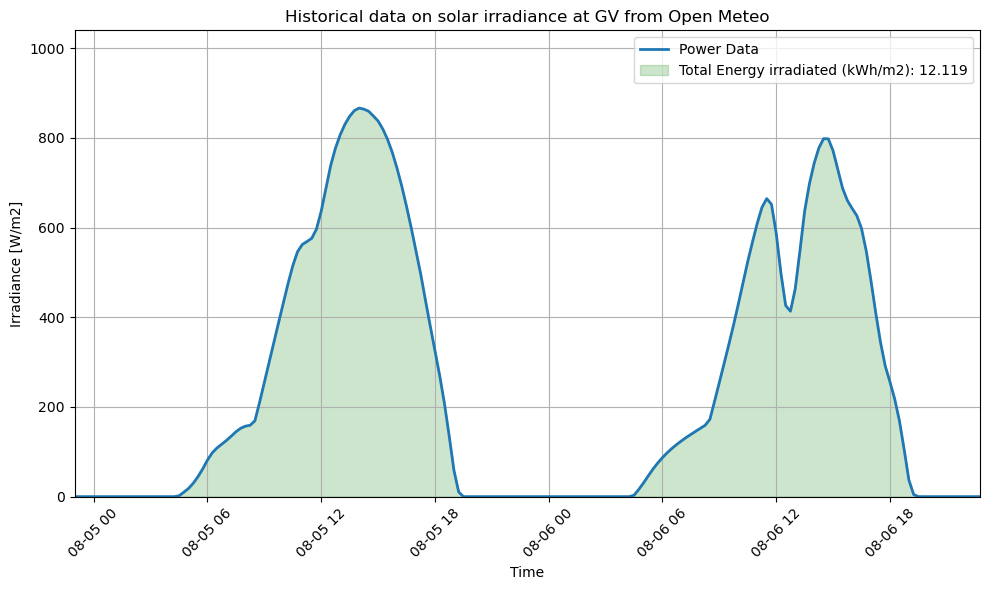

In [23]:
# Openmeteo historical data:
import openmeteo_requests

import requests_cache
import pandas as pd
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://historical-forecast-api.open-meteo.com/v1/forecast"
params = {
	"latitude": 52.00667,
	"longitude": 4.35556,
	"start_date": "2024-08-05",
	"end_date": "2024-08-06",
	"minutely_15": ["temperature_2m", "global_tilted_irradiance"],
	"hourly": ["temperature_2m", "global_tilted_irradiance"],
	"timezone": "auto",
	"tilt": 45,
	"azimuth": 67
}
responses = openmeteo.weather_api(url, params=params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation {response.Elevation()} m asl")
print(f"Timezone {response.Timezone()} {response.TimezoneAbbreviation()}")
print(f"Timezone difference to GMT+0 {response.UtcOffsetSeconds()} s")

# Process minutely_15 data. The order of variables needs to be the same as requested.
minutely_15 = response.Minutely15()
minutely_15_temperature_2m = minutely_15.Variables(0).ValuesAsNumpy()
minutely_15_global_tilted_irradiance = minutely_15.Variables(1).ValuesAsNumpy()

minutely_15_data = {"date": pd.date_range(
	start = pd.to_datetime(minutely_15.Time(), unit = "s", utc = True),
	end = pd.to_datetime(minutely_15.TimeEnd(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = minutely_15.Interval()),
	inclusive = "left"
)}
minutely_15_data["temperature_2m"] = minutely_15_temperature_2m
minutely_15_data["global_tilted_irradiance"] = minutely_15_global_tilted_irradiance

minutely_15_dataframe = pd.DataFrame(data = minutely_15_data)
print(minutely_15_dataframe)

# Process hourly data. The order of variables needs to be the same as requested.
hourly = response.Hourly()
hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()
hourly_global_tilted_irradiance = hourly.Variables(1).ValuesAsNumpy()

hourly_data = {"date": pd.date_range(
	start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
	end = pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = hourly.Interval()),
	inclusive = "left"
)}
hourly_data["temperature_2m"] = hourly_temperature_2m
hourly_data["global_tilted_irradiance"] = hourly_global_tilted_irradiance


TemperatureHR = pd.DataFrame({ # Make a DF that works with my scripts
        'time': pd.to_datetime(hourly_data['date']),  # Converts to datetime objectdf['validdate'],
        'value_float': hourly_temperature_2m,
        'device_id': 'forecaster',
        'measurement_id': 'termperature'
        })

GTIHR = pd.DataFrame({ # Make a DF that works with my scripts
        'time': pd.to_datetime(hourly_data['date']),  # Converts to datetime objectdf['validdate'],
        'value_float': hourly_global_tilted_irradiance,
        'device_id': 'forecaster',
        'measurement_id': 'irradiance'
        })


Temperaturemin = pd.DataFrame({ # Make a DF that works with my scripts
        'time': pd.to_datetime(minutely_15_data['date']),  # Converts to datetime objectdf['validdate'],
        'value_float': minutely_15_temperature_2m,
        'device_id': 'forecaster',
        'measurement_id': 'termperature'
        })

GTImin = pd.DataFrame({ # Make a DF that works with my scripts
        'time': pd.to_datetime(minutely_15_data['date']),  # Converts to datetime objectdf['validdate'],
        'value_float': minutely_15_global_tilted_irradiance,
        'device_id': 'forecaster',
        'measurement_id': 'irradiance'
        })



fplot('GTIHR')

fplot('TemperatureHR')

fplot('GTImin')
fplot('Temperaturemin')

IrradianceEnergy = integrate_hr_forecast('GTImin')[1]


Also irradiance data was gathered during these days from the green village office lab roof by a Davis pyranometer:

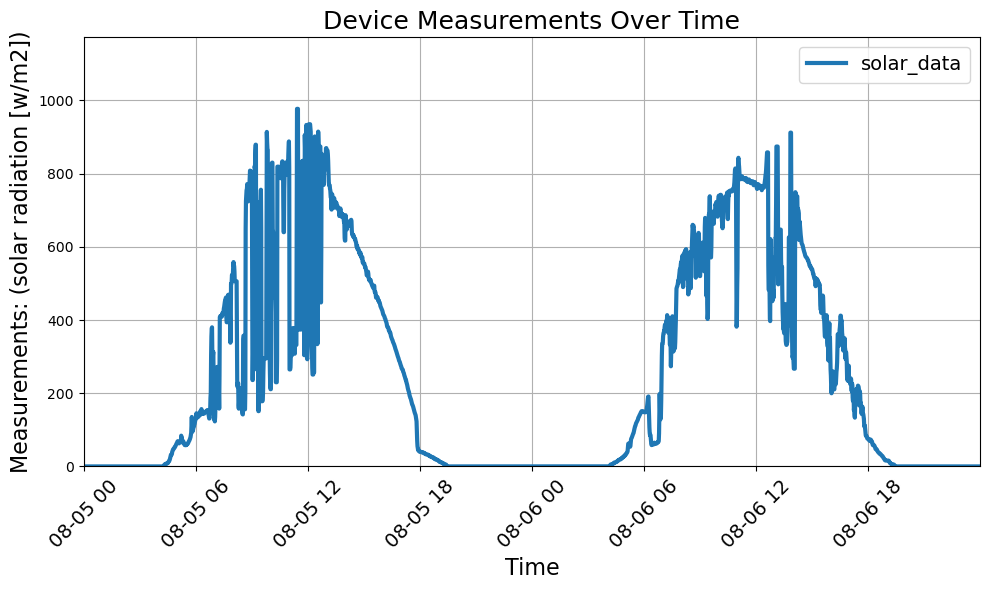

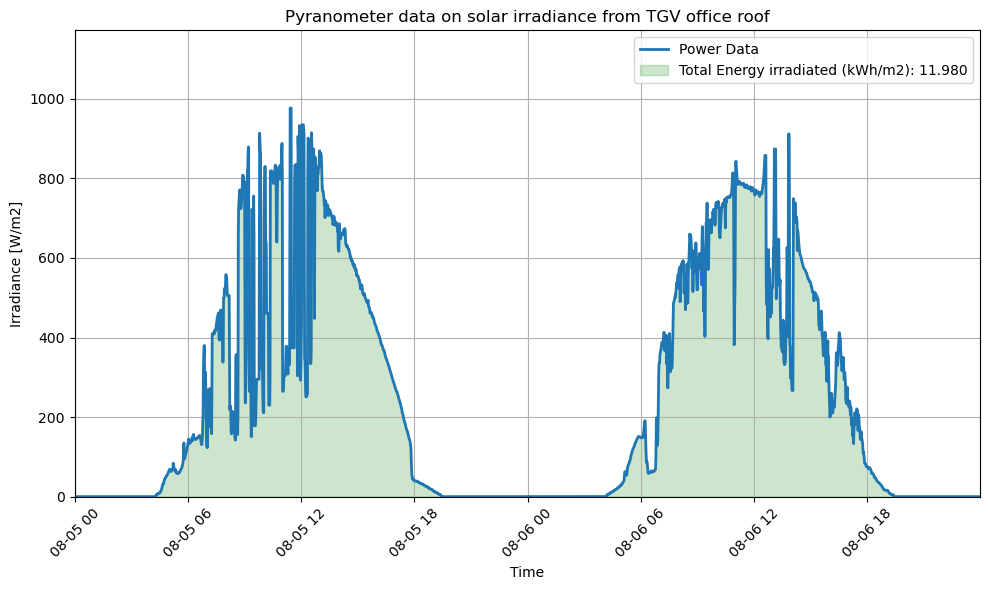

Available solar irradiance:, 287.25 kWh


In [25]:
solar_data['device_id'] = 'weatherstation'
solar_data['measurement_id'] = 'solar radiation [w/m2]'
solar_data.rename(columns={'value_int': 'value_float'}, inplace=True)

fplot('solar_data')
PyranoEnergy = integrate_hr_pyrano('solar_data')[1] # per m2

AreaPP = 1.762*1.134 # m2/panel
solarAvailable = PyranoEnergy*12*AreaPP # 5340 Wp installed capacity with 445 Wp panels,so 5340/445 or 12 panels, with 
print(f"Available solar irradiance:, {solarAvailable:.2f} kWh")

### PV Data
First, at the beginning of the chain, the PV panels of the 24/7 energyhub will be examined. The panels consist of 12 440 Wp panels. Also, irradiance data is imported measured from the roof of the Green village officelab. the data is given in w/m2. The data is collected for one week of operation. The given data is the active inverter output power, so after all conversions. The GV energy hub has 12 440Wp panels of 1.762*1.134 # m2/panel


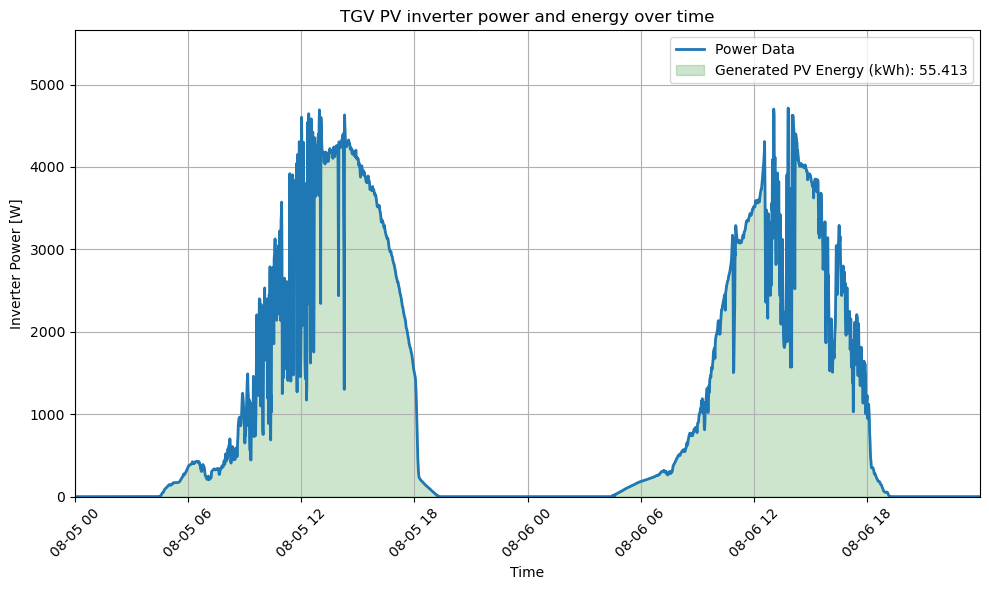

Energy generated by panels: 55.41 kWh
Solar energy irradiated (GTI): 290.58 kWh
Efficiency from irradiance to PV inverter output is: 19.07 %
The difference in openMeteo data and the pyranometer at the roof is: 1.15 %


In [27]:
PVenergy = integrate_hr_inverter("PV_Inverter_Active_Power")[1]
AreaPP = 1.762*1.134 # m2/panel

print(f"Energy generated by panels: {PVenergy:.2f} kWh")
print(f"Solar energy irradiated (GTI): {12*AreaPP*IrradianceEnergy:.2f} kWh")
print(f"Efficiency from irradiance to PV inverter output is: {PVenergy/(12*AreaPP*IrradianceEnergy)*100:.2f} %")
print(f"The difference in openMeteo data and the pyranometer at the roof is: {100*(IrradianceEnergy-PyranoEnergy)/(IrradianceEnergy):.2f} %")

### Battery Data

The battery is used to provide electricity to the student home and produce hydrogen when a state of charge of 80% is reached. This is clearly visible in the AC Power out, which spikes up when the Hydrogen production is enabled at 80% SoC.

Loaded Battery_Current from ./All dataframes/dataframes-1-min-2
Loaded Battery_Inverter_AC_In_Power from ./All dataframes/dataframes-1-min-2
Loaded Battery_Inverter_AC_Out_Power from ./All dataframes/dataframes-1-min-2
Loaded Battery_Inverter_Grid_Setpoint from ./All dataframes/dataframes-1-min-2
Loaded Battery_Power from ./All dataframes/dataframes-1-min-2
Loaded Battery_State_Of_Charge from ./All dataframes/dataframes-1-min-2
Loaded Battery_Temperature from ./All dataframes/dataframes-1-min-2
Loaded Battery_Voltage from ./All dataframes/dataframes-1-min-2
Loaded Temperature_Monitoring_Battery_Cabinet_Temperature from ./All dataframes/dataframes-1-min-2


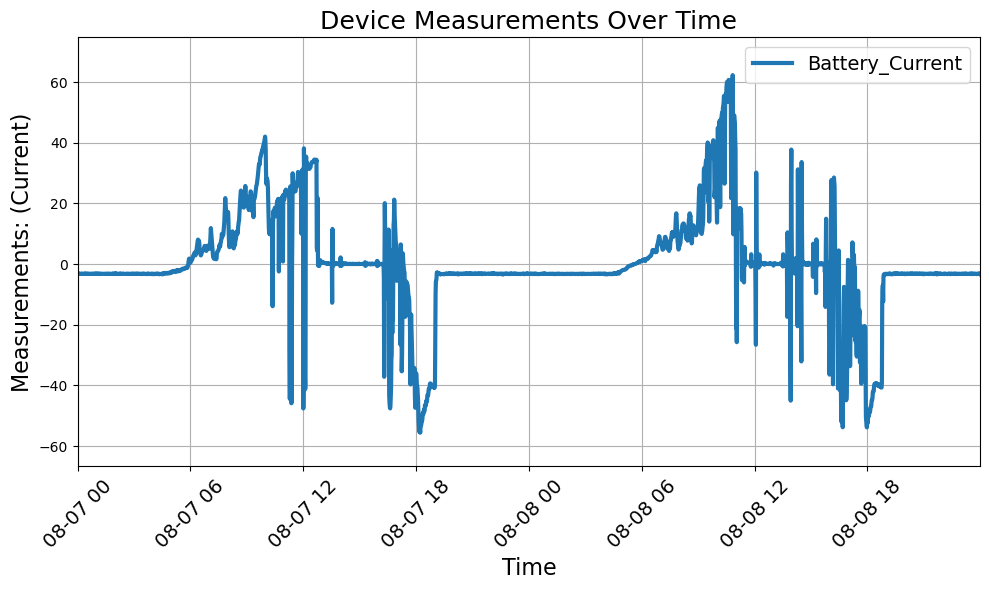

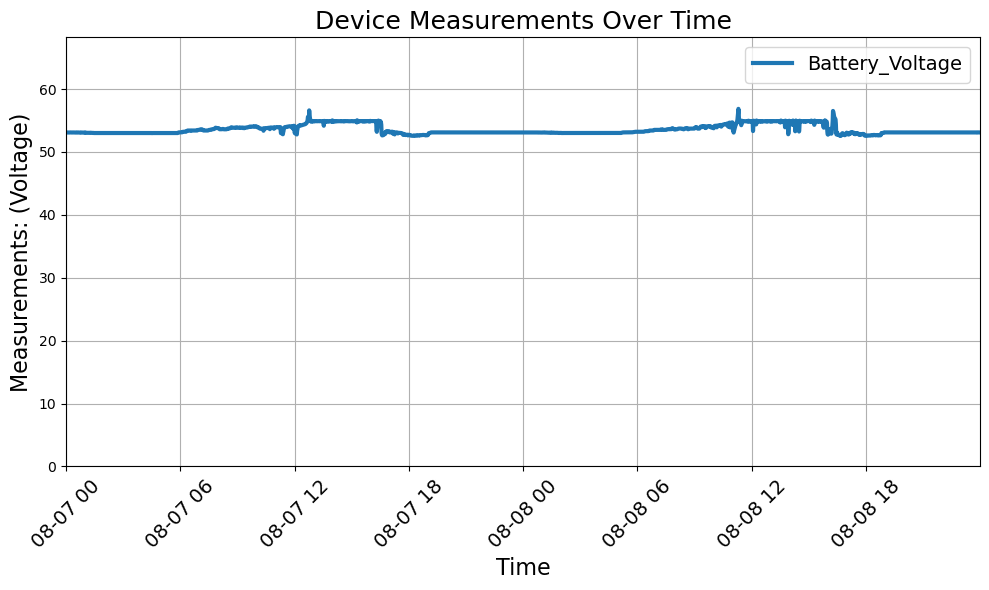

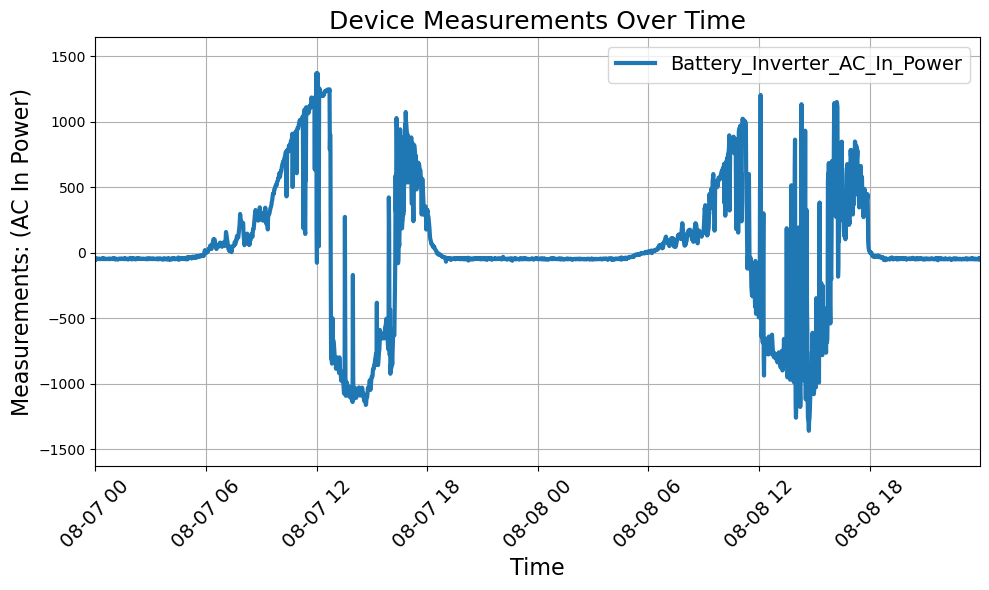

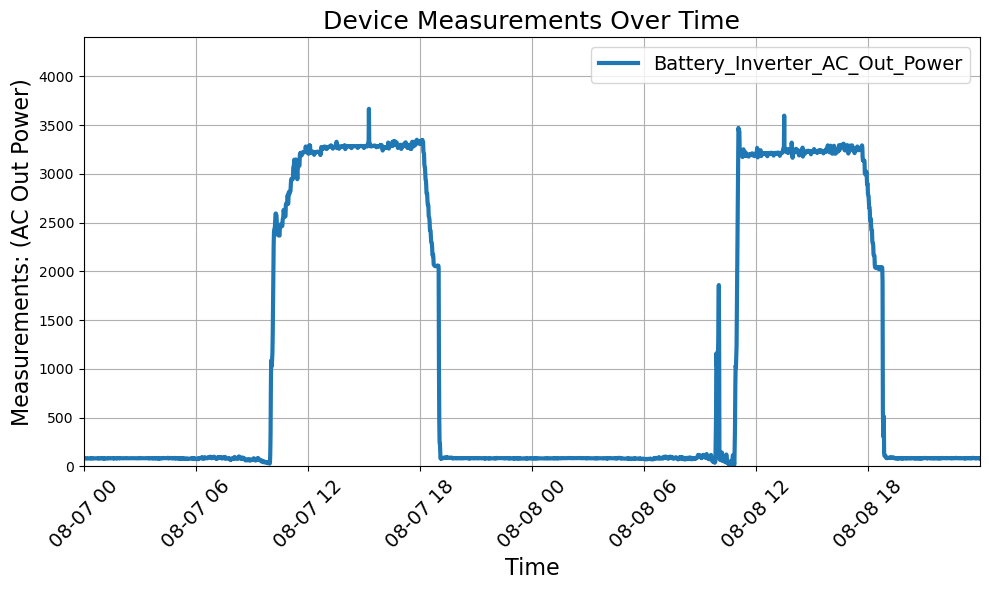

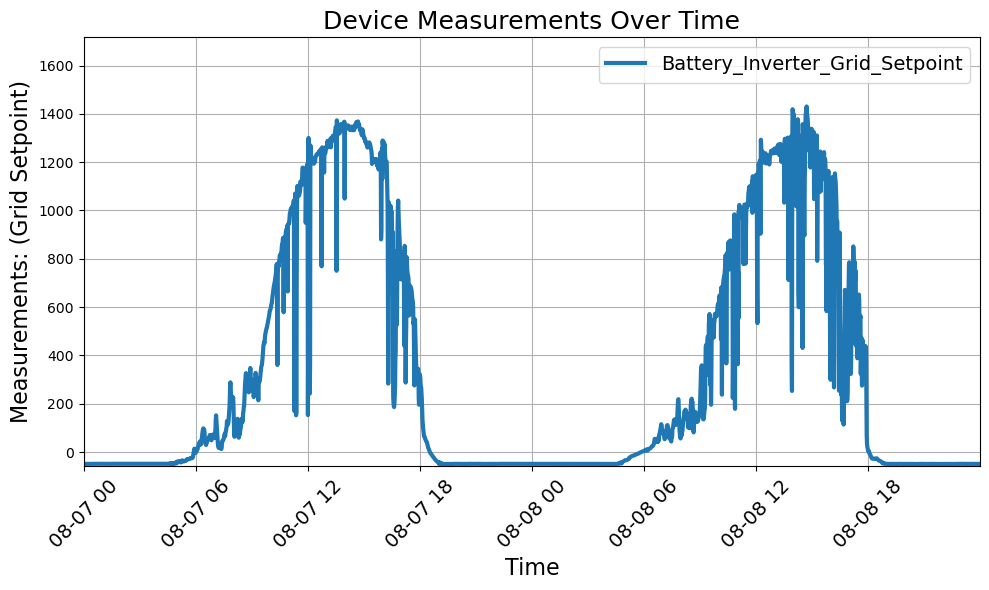

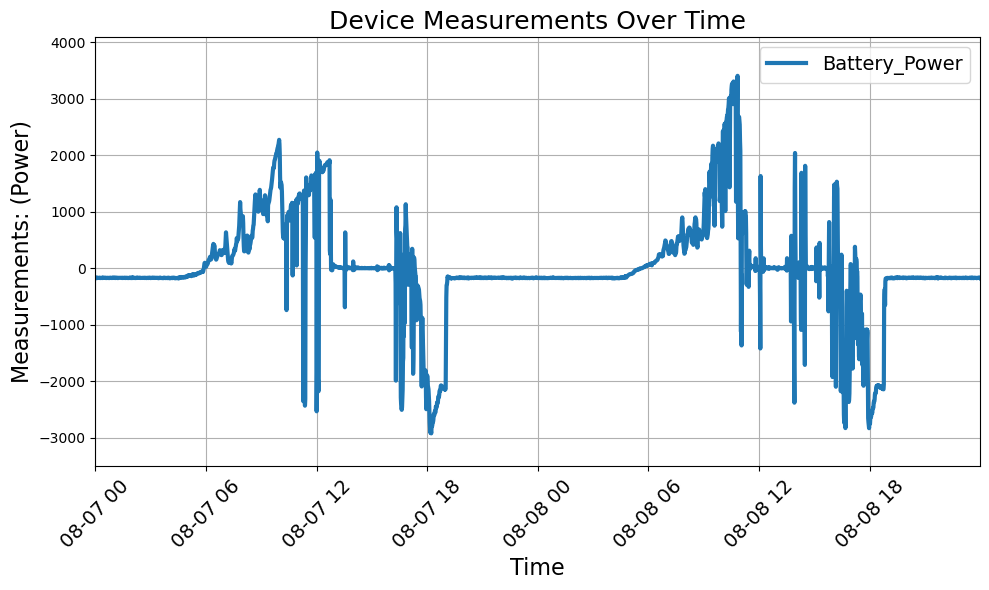

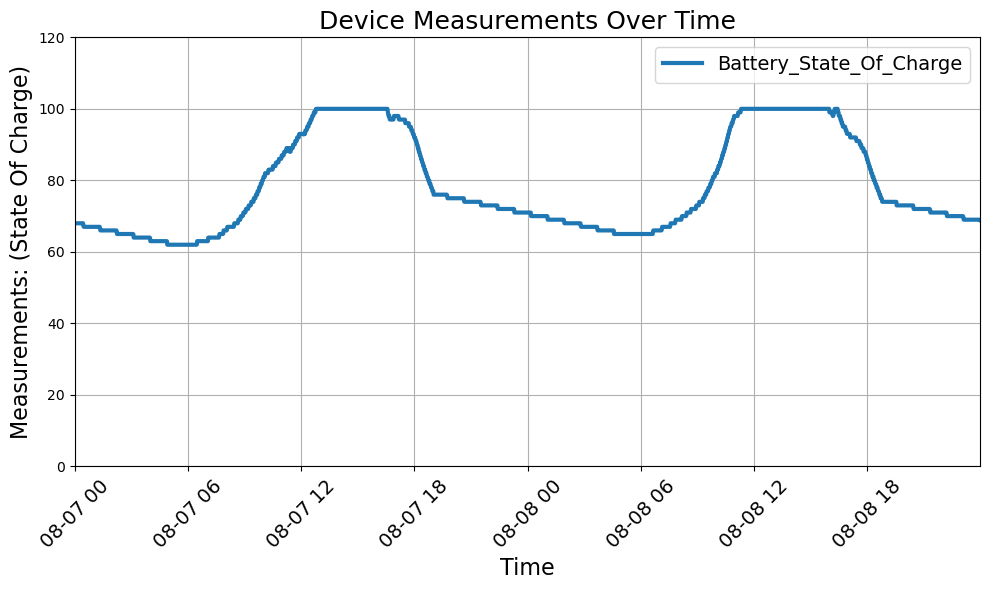

,time,value_float,device_id,measurement_id,application_id,name
0,2024-08-07 00:00:00+00:00,-174.765333,Battery,Power,Battery System,Seasonal_Storage_System
1,2024-08-07 00:01:00+00:00,-170.185500,Battery,Power,Battery System,Seasonal_Storage_System
2,2024-08-07 00:02:00+00:00,-166.338000,Battery,Power,Battery System,Seasonal_Storage_System
3,2024-08-07 00:03:00+00:00,-170.341333,Battery,Power,Battery System,Seasonal_Storage_System
4,2024-08-07 00:04:00+00:00,-175.976833,Battery,Power,Battery System,Seasonal_Storage_System


In [134]:
# Importing data
DataframesToLoad = ["Battery_Current", "Battery_Inverter_AC_In_Power", "Battery_Inverter_AC_Out_Power" ,"Battery_Inverter_Grid_Setpoint", "Battery_Power", 
                    "Battery_State_Of_Charge", "Battery_Temperature","Battery_Voltage", "Temperature_Monitoring_Battery_Cabinet_Temperature"]

for var_name in DataframesToLoad:
    globals()[var_name] = pd.read_pickle(os.path.join(subfolder, f"{var_name}.pkl"))
    print(f"Loaded {var_name} from {subfolder}")



fplot("Battery_Current")
# Positive = charging battery
# Negative = discharging battery

fplot("Battery_Voltage")
# Voltage of the battery

fplot("Battery_Inverter_AC_In_Power")
# Positive = Energy taken from grid
# Negative = Energy sent to the grid

fplot("Battery_Inverter_AC_Out_Power")
# Output power to all consumers in the container

fplot("Battery_Inverter_Grid_Setpoint")
# Setpoint as requested: positive: Take energy from the grid
# Setpoint as requested: negative: Send energy to the grid

fplot("Battery_Power")
# Battery power
# Positive = charging battery
# Negative = discharging battery

fplot("Battery_State_Of_Charge")
# Battery power
# Positive = charging battery
# Negative = discharging battery


Battery_Power.head()


In [162]:


def integrate_hr_batteryDC(var):
    if var in globals():
        data = globals()[var]
        time = data['time']
        values = data['value_float']
        time_numeric = (time - time.iloc[0]).dt.total_seconds().astype(int)
        
        # Separate positive and negative data
        positive_values = np.where(values > 0, values, 0)
        negative_values = np.where(values < 0, values, 0)
        kWh_pos = np.trapz(positive_values, time_numeric) / 3600000  # Integration for positive values
        kWh_neg = np.trapz(negative_values, time_numeric) / 3600000  # Integration for negative values
        joules = np.trapz(values, time_numeric)
        energy_kWh = joules / 3600000
    else:
        print(f"Variable '{var}' not found!")  
        return None, None, None

    # Plotting
    plt.figure(figsize=figdim)
    plt.plot(time, values, label='Power Data', linewidth = 2)
    plt.fill_between(time, positive_values, alpha=0.2, label=f'Battery charging [kWh]: {kWh_pos:.3f}', color='green')
    
    # Plot negative energy only if it exists
    if np.any(negative_values != 0):  # Check if there are non-zero negative values
        plt.fill_between(time, negative_values, alpha=0.2, label=f'Battery discharging [kWh]: {kWh_neg:.3f}', color='red')
    
    plt.xlabel('Time')
    plt.ylabel('Battery DC output Power [W]')
    plt.xlim(min(time), max(time))
    plt.ylim(min(values),max(values)*1.2)
    plt.title('Energy hub battery DC output power')
    plt.legend(loc='upper left')  # Set legend location to top-right corner
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"figures/Solar Report/Battery Power DC.png")
    plt.show()

    return energy_kWh, kWh_pos, kWh_neg


def integrate_hr_battery(var):
    if var in globals():
        data = globals()[var]
        time = data['time']
        values = data['value_float']
        time_numeric = (time - time.iloc[0]).dt.total_seconds().astype(int)
        
        # Separate positive and negative data
        positive_values = np.where(values > 0, values, 0)
        negative_values = np.where(values < 0, values, 0)
        kWh_pos = np.trapz(positive_values, time_numeric) / 3600000  # Integration for positive values
        kWh_neg = np.trapz(negative_values, time_numeric) / 3600000  # Integration for negative values
        joules = np.trapz(values, time_numeric)
        energy_kWh = joules / 3600000
    else:
        print(f"Variable '{var}' not found!")  
        return None, None, None

    # Plotting
    plt.figure(figsize=figdim)
    plt.plot(time, values, label='Power Data', linewidth = 2)
    plt.fill_between(time, positive_values, alpha=0.2, label=f'Battery charging [kWh]: {kWh_pos:.3f}', color='green')
    
    # Plot negative energy only if it exists
    if np.any(negative_values != 0):  # Check if there are non-zero negative values
        plt.fill_between(time, negative_values, alpha=0.2, label=f'Battery discharging [kWh]: {kWh_neg:.3f}', color='red')
    
    plt.xlabel('Time')
    plt.ylabel('Output Power after inverter [W]')
    plt.xlim(min(time), max(time))
    plt.ylim(min(values),max(values)*1.2)
    plt.title('Energy hub battery power')
    plt.legend(loc='upper left')  # Set legend location to top-right corner
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"figures/Solar Report/Battery Power.png")
    plt.show()

    return energy_kWh, kWh_pos, kWh_neg


def integrate_hr_container(var):
    if var in globals():
        data = globals()[var]
        time = data['time']
        values = data['value_float']
        time_numeric = (time - time.iloc[0]).dt.total_seconds().astype(int)
        
        # Separate positive and negative data
        positive_values = np.where(values > 0, values, 0)
        negative_values = np.where(values < 0, values, 0)
        kWh_pos = np.trapz(positive_values, time_numeric) / 3600000  # Integration for positive values
        kWh_neg = np.trapz(negative_values, time_numeric) / 3600000  # Integration for negative values
        joules = np.trapz(values, time_numeric)
        energy_kWh = joules / 3600000
    else:
        print(f"Variable '{var}' not found!")  
        return None, None, None

    # Plotting
    plt.figure(figsize=figdim)
    plt.plot(time, values, label='Power Data', linewidth = 2, color = 'red')
    plt.fill_between(time, positive_values, alpha=0.2, label=f'Energy consumed [kWh]: {kWh_pos:.3f}', color='red')
    
    # Plot negative energy only if it exists
    if np.any(negative_values != 0):  # Check if there are non-zero negative values
        plt.fill_between(time, negative_values, alpha=0.2, label=f'Battery discharging [kWh]: {kWh_neg:.3f}', color='red')
    
    plt.xlabel('Time')
    plt.ylabel('Power consumed by container [W]')
    plt.xlim(min(time), max(time))
    plt.ylim(min(values),max(values)*1.2)
    plt.title('Energy hub power consumption')
    plt.legend(loc='upper left')  # Set legend location to top-right corner
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"figures/Solar Report/Battery Power Container.png")
    plt.show()

    return energy_kWh, kWh_pos, kWh_neg


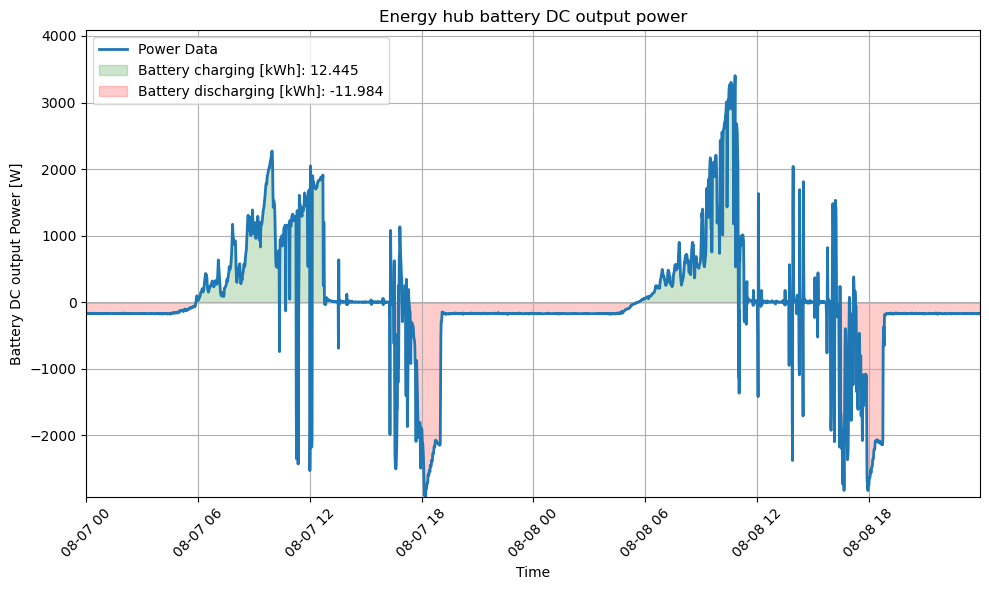

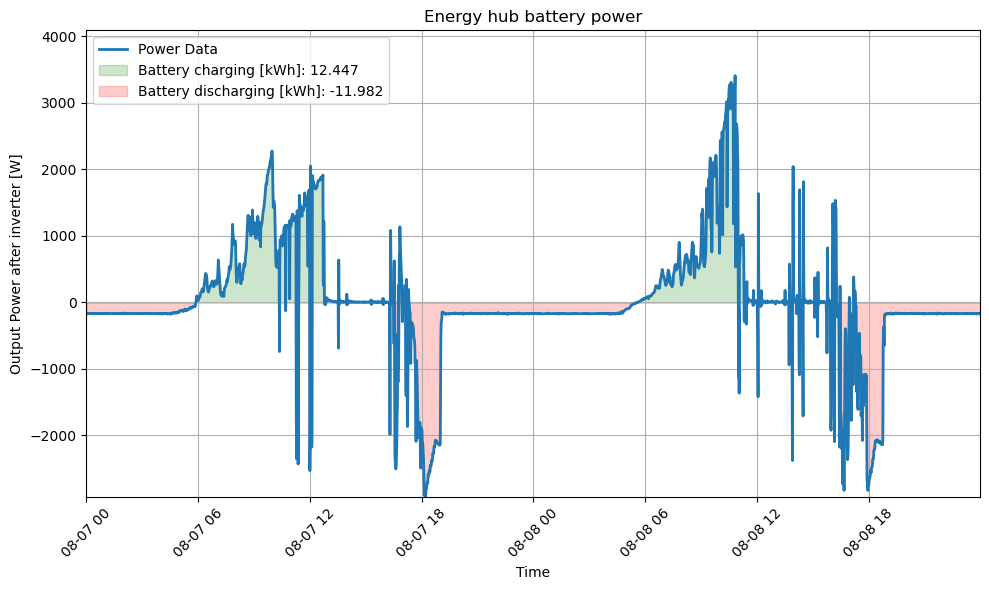

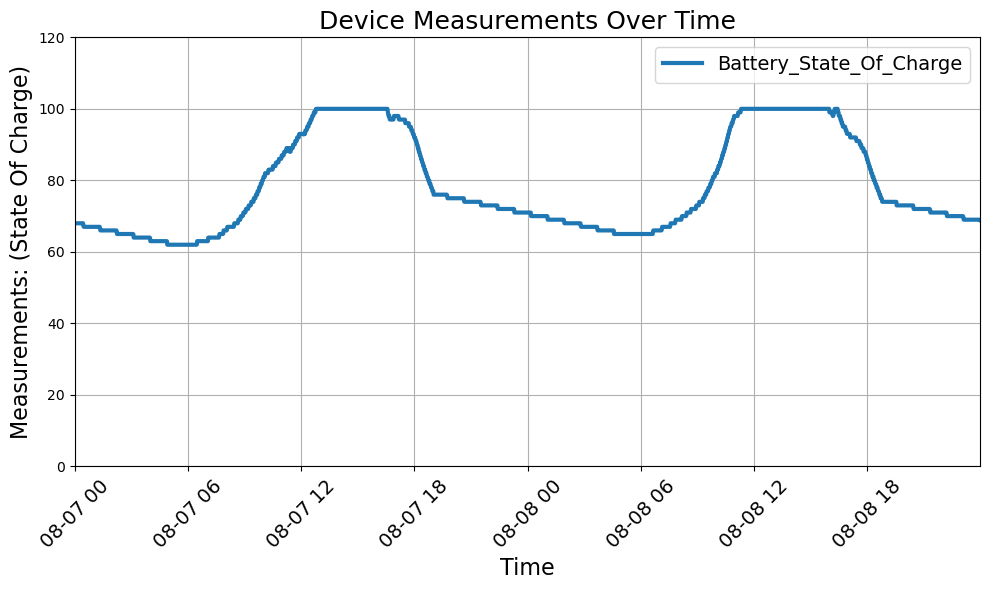

In [168]:
# Create a DataFrame to store the temperature
DC_Power = Battery_Current['value_float']*Battery_Voltage['value_float']

DC_Power = pd.DataFrame({
    "time": Battery_Current['time'],
    "value_float": DC_Power,
    "device_id": "Battery",
    "measurement_id": "dc power",
    "application_id": "Battery System",
    "name": "Seasonal storage system"
})

integrate_hr_batteryDC('DC_Power')
integrate_hr_battery('Battery_Power')
fplot('Battery_State_Of_Charge')

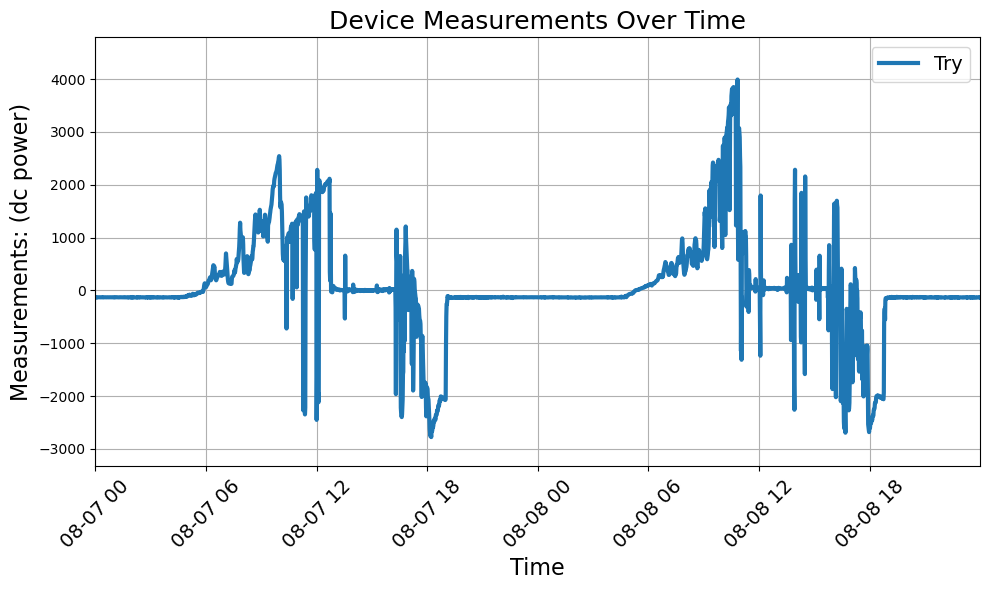

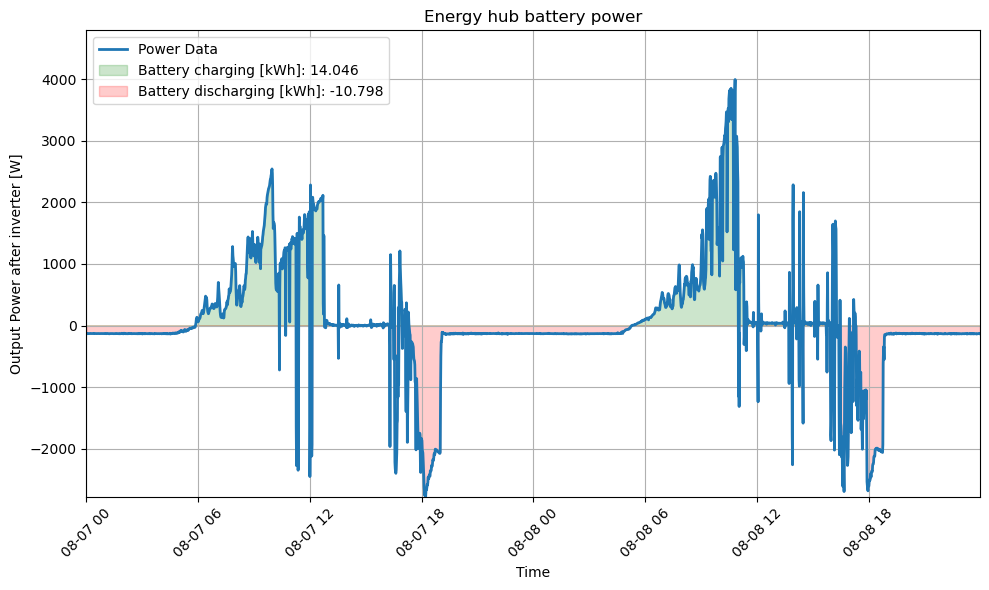

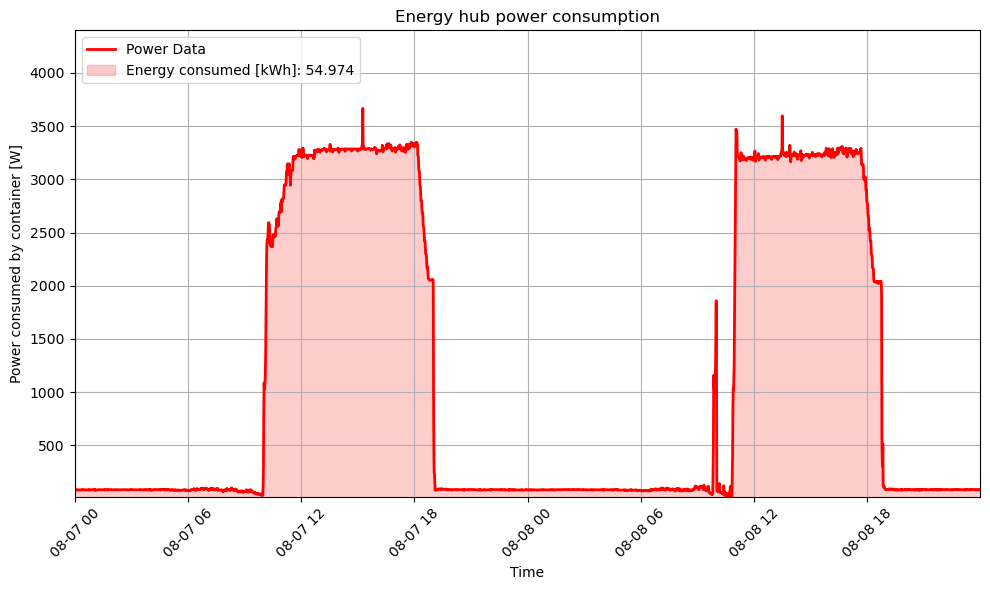

Energy difference: 3.999999999997783 [Wh]
Energy difference: 99.98362735868365 [Wh]


In [184]:
# Create a DataFrame to store the temperature
Try = PV_Inverter_Active_Power['value_float'] - Battery_Inverter_AC_Out_Power['value_float'] + Battery_Inverter_AC_In_Power['value_float']
# Power in - Power out + Power in

Try = pd.DataFrame({
    "time": Battery_Current['time'],
    "value_float": Try,
    "device_id": "Battery",
    "measurement_id": "dc power",
    "application_id": "Battery System",
    "name": "Seasonal storage system"
})

fplot("Try")
integrate_hr_battery("Try")
integrate_hr_container("Battery_Inverter_AC_Out_Power")

inverteruse = 1000*(12.447+11.984-12.445-11.982)
print(f"Energy difference: {inverteruse} [Wh]")
print(f"Energy difference: {100*(1-(inverteruse/1000/(12.447+11.984)))} [Wh]")